<div style="display:flex; align-items:center;">
  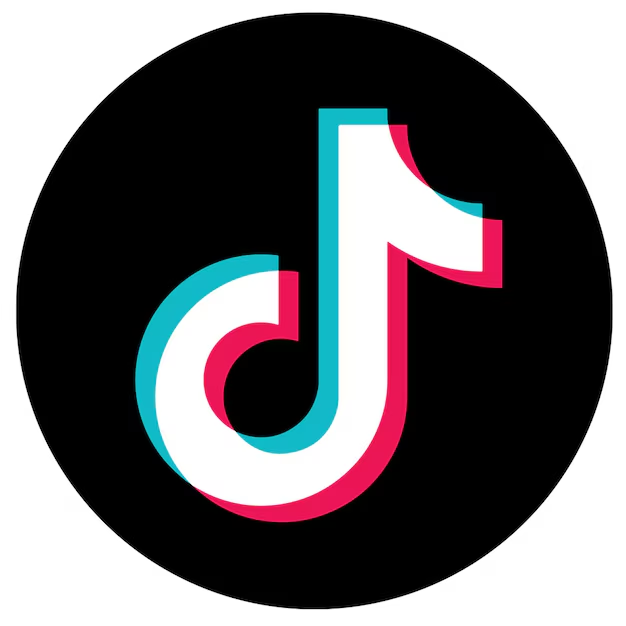
  <h1 style="margin:0 0 0 10px; line-height:50px;">TikTok Video Classification Project</h1>
</div>

TikTok users have the ability to submit reports that identify videos and comments that contain user claims. These reports identify content that needs to be reviewed by moderators. The process generates a large number of user reports that are challenging to consider in a timely manner. 

TikTok is working on the development of a predictive model that can determine whether a video contains a claim or offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

In [3]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing and modeling
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, train_test_split, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import xgboost

from xgboost import plot_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

In [5]:
# Display and examine the first few rows of the dataframe
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [6]:
# Get basic information about the data and determine how many null values are present
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [7]:
# Generate a table of descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [8]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [9]:
# Drop rows with missing values
data_subset = data.dropna()
data_subset.shape

(19084, 12)

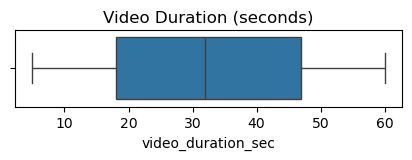

In [10]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(5, 1))
sns.boxplot(x=data['video_duration_sec'])
plt.title('Video Duration (seconds)')
plt.show()

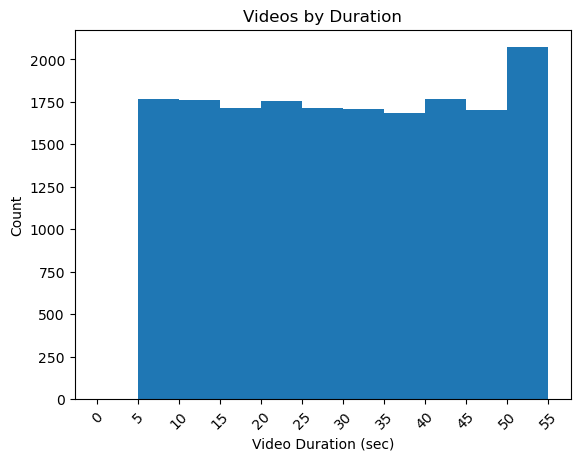

In [11]:
# Create a histogram
plt.hist(data['video_duration_sec'], bins=range(0, 60, 5))

plt.xticks(range(0, 60, 5), rotation=45)
plt.xlabel('Video Duration (sec)')

plt.ylabel('Count')

plt.title('Videos by Duration')
plt.show()

**The videos lenghts are fairly evenly distributed and range between 5 and 55 seconds. There are no obvious outliers.**

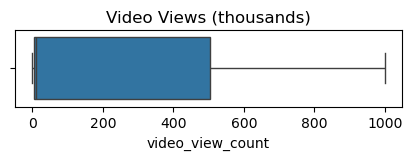

In [13]:
# Create a boxplot to visualize distribution of `video_view_count`
views_k = data['video_view_count'] / 1000

plt.figure(figsize=(5, 1))
sns.boxplot(x=views_k)
plt.title('Video Views (thousands)')
plt.show()

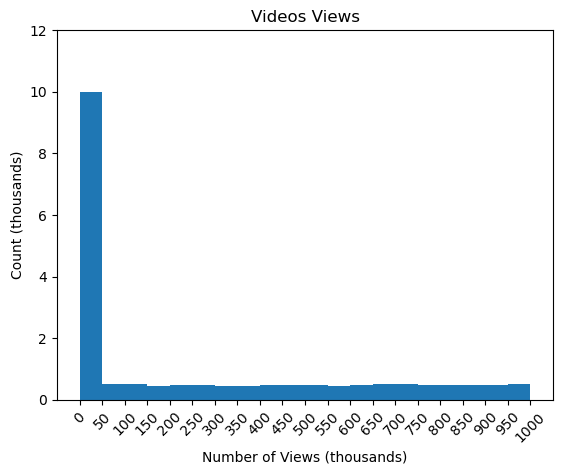

In [14]:
# Create a histogram
plt.hist(views_k, bins=range(0, 1001, 50))

plt.xticks(range(0, 1001, 50), rotation=45)
plt.xlabel('Number of Views (thousands)')

yticks = plt.yticks()[0]
plt.yticks(yticks, labels=(yticks/1000).astype(int))
plt.ylabel('Count (thousands)')

plt.title('Videos Views')
plt.show()

**There are less than 50 views nearing one million views. This may be bad data, but more likely represents a handful of viral videos.**

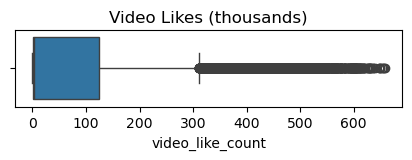

In [16]:
# Create a boxplot to visualize distribution of `video_like_count`
likes_k = data['video_like_count'] / 1000

plt.figure(figsize=(5, 1))
sns.boxplot(x=likes_k)
plt.title('Video Likes (thousands)')
plt.show()

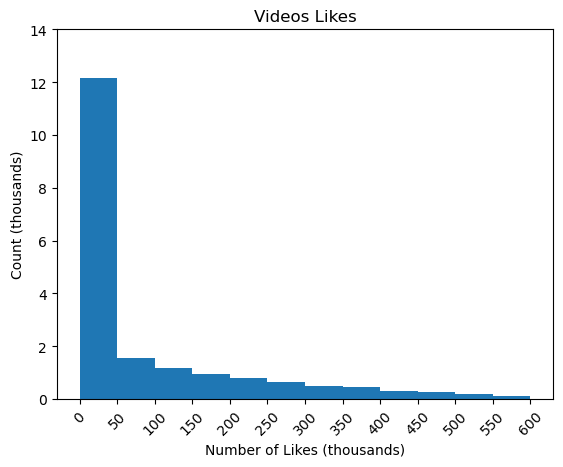

In [17]:
# Create a histogram
plt.hist(likes_k, bins=range(0, 650, 50))

plt.xticks(range(0, 650, 50), rotation=45)
plt.xlabel('Number of Likes (thousands)')

yticks = plt.yticks()[0]
plt.yticks(yticks, labels=(yticks/1000).astype(int))
plt.ylabel('Count (thousands)')

plt.title('Videos Likes')
plt.show()

**The number of video "likes" is inversely proportional to the number of views. Videos with the most views consistenly receive the most likes.**

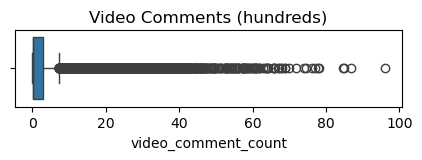

In [19]:
# Create a boxplot to visualize distribution of `video_comment_count`
comments_h = data['video_comment_count'] / 100

plt.figure(figsize=(5, 1))
sns.boxplot(x=comments_h)
plt.title('Video Comments (hundreds)')
plt.show()

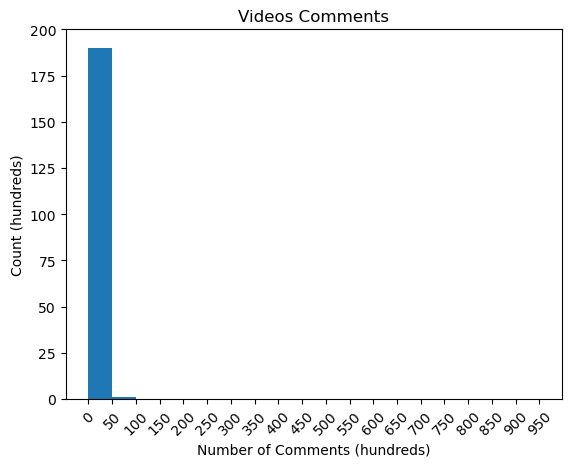

In [20]:
# Create a histogram
plt.hist(comments_h, bins=range(0, 1000, 50))

plt.xticks(range(0, 1000, 50), rotation=45)
plt.xlabel('Number of Comments (hundreds)')

yticks = plt.yticks()[0]
plt.yticks(yticks, labels=(yticks/100).astype(int))
plt.ylabel('Count (hundreds)')

plt.title('Videos Comments')
plt.show()

**The number of comments is also proportional to the number of views. However, comments are mostly limited to the videos with a high number of views.**

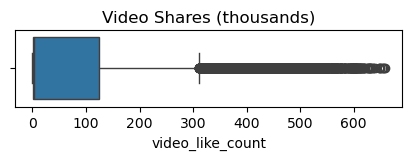

In [22]:
# Create a boxplot to visualize distribution of `video_share_count`
shares_k = data['video_share_count'] / 1000

plt.figure(figsize=(5, 1))
sns.boxplot(x=likes_k)
plt.title('Video Shares (thousands)')
plt.show()

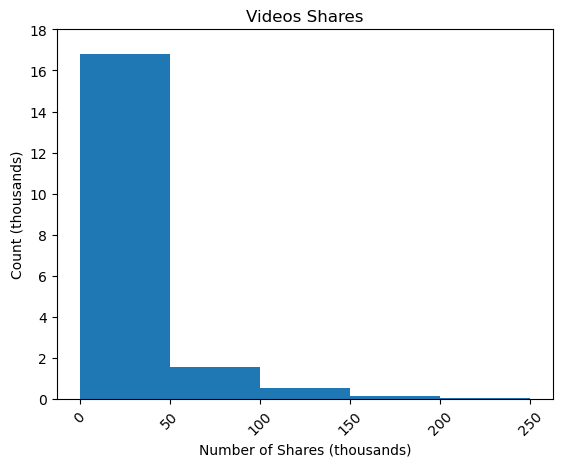

In [23]:
# Create a histogram
plt.hist(shares_k, bins=range(0, 300, 50))

plt.xticks(range(0, 300, 50), rotation=45)
plt.xlabel('Number of Shares (thousands)')

yticks = plt.yticks()[0]
plt.yticks(yticks, labels=(yticks/1000).astype(int))
plt.ylabel('Count (thousands)')

plt.title('Videos Shares')
plt.show()

**The number of video shares is skewed to the right.**

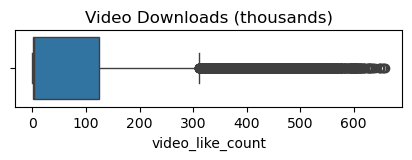

In [25]:
# Create a boxplot to visualize distribution of `video_download_count`
downloads_k = data['video_download_count'] / 1000

plt.figure(figsize=(5, 1))
sns.boxplot(x=likes_k)
plt.title('Video Downloads (thousands)')
plt.show()

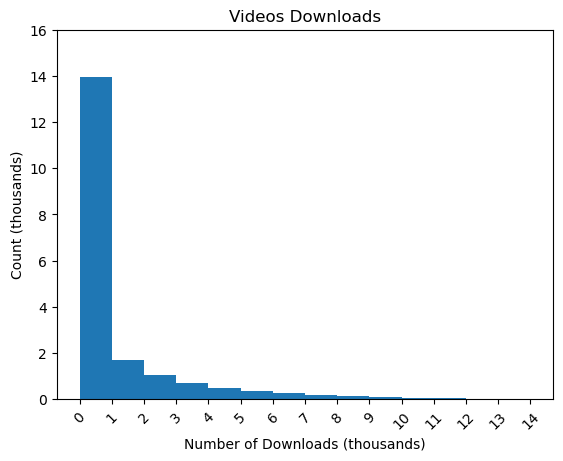

In [26]:
# Create a histogram
plt.hist(downloads_k, bins=range(0, 15, 1))

plt.xticks(range(0, 15, 1), rotation=45)
plt.xlabel('Number of Downloads (thousands)')

yticks = plt.yticks()[0]
plt.yticks(yticks, labels=(yticks/1000).astype(int))
plt.ylabel('Count (thousands)')

plt.title('Videos Downloads')
plt.show()

**The number of video downloads is also skewed to the right.**

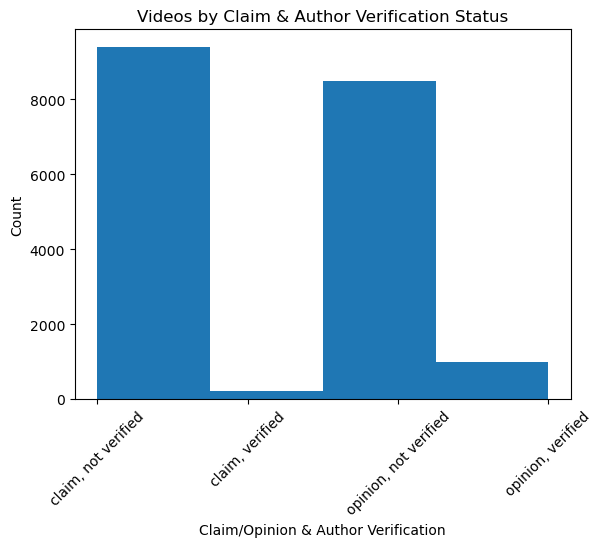

In [28]:
# Create a histogram
claim_verified_labels = data[['claim_status', 'verified_status']].dropna().agg(', '.join, axis=1) #drop NaN values

# claim_verified_labels.head(10)

plt.hist(claim_verified_labels, bins=4)
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.xlabel('Claim/Opinion & Author Verification')
plt.title('Videos by Claim & Author Verification Status')
plt.show()

**Most of the posted videos are by unverified users. While the number of videos that represent "Claims" versus "Opinions" is relatively balanced, there are slightly more "Claims", which tend to be posted by unverified users".**

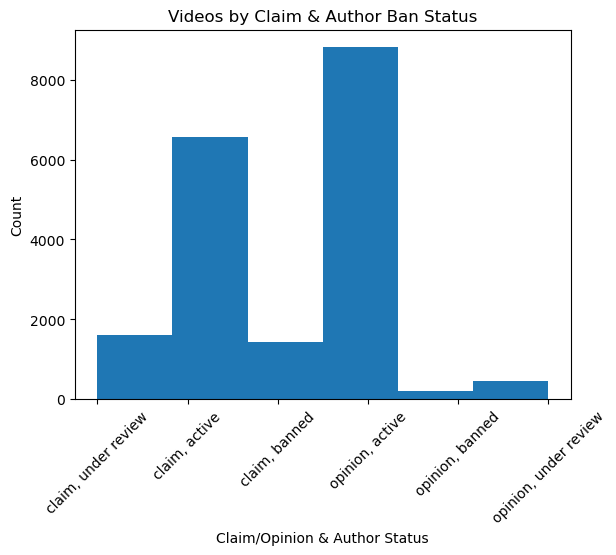

In [30]:
# Create a histogram
claim_banned_labels = data[['claim_status', 'author_ban_status']].dropna().agg(', '.join, axis=1)  #drop NaN values

#data['author_ban_status'].unique()
#claim_banned_labels.head(10)

plt.hist(claim_banned_labels, bins=6)
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.xlabel('Claim/Opinion & Author Status')
plt.title('Videos by Claim & Author Ban Status')
plt.show()

**There are far fewer videos posted by authors that have been banned or are under review.**

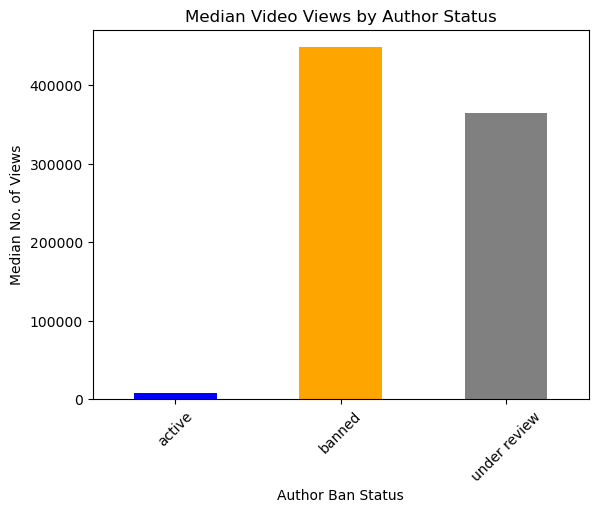

In [32]:
# Create a bar plot
author_views_by_status = data.groupby('author_ban_status')['video_view_count'].median()

# author_views_by_status

author_views_by_status.plot(kind='bar', color=['blue', 'orange', 'gray'])
plt.ylabel('Median No. of Views')
plt.xlabel('Author Ban Status')
plt.title('Median Video Views by Author Status')
plt.xticks(rotation=45)
plt.show()

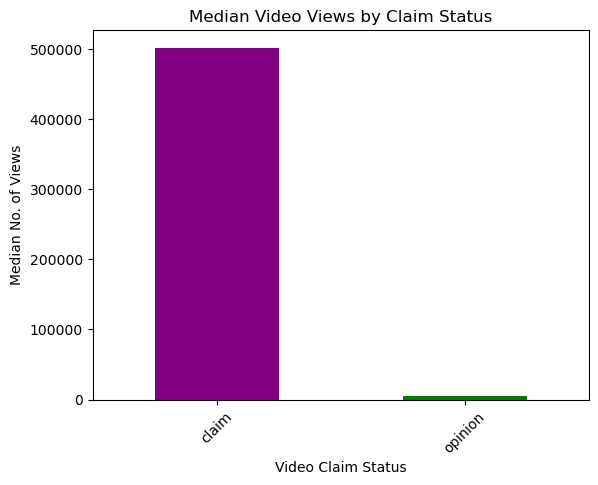

In [33]:
# Calculate the median view count for claim status.
views_by_claim_status = data.groupby('claim_status')['video_view_count'].median()

# views_by_claim_status

views_by_claim_status.plot(kind='bar', color=['purple', 'green'])
plt.ylabel('Median No. of Views')
plt.xlabel('Video Claim Status')
plt.title('Median Video Views by Claim Status')
plt.xticks(rotation=45)
plt.show()

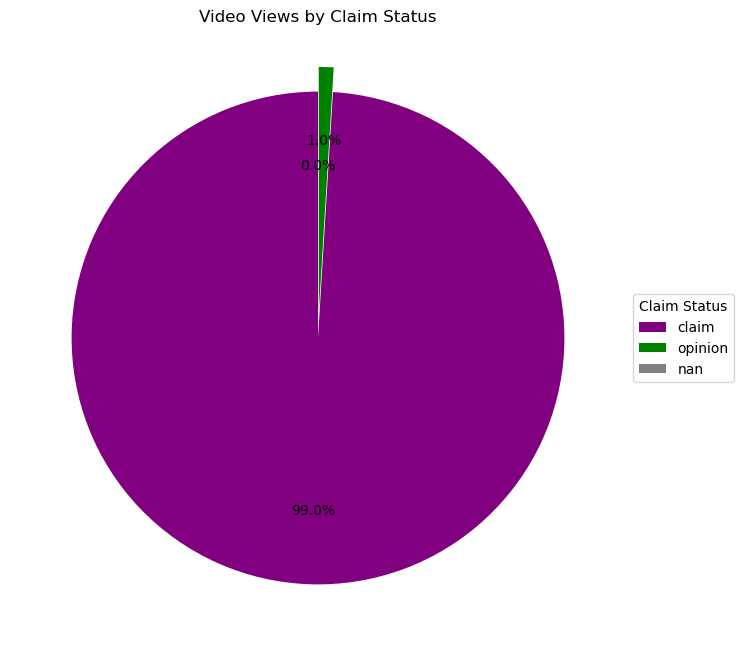

In [34]:
# Create a pie graph
claim_status_labels = data['claim_status'].unique()
video_views = data.groupby('claim_status', dropna=False)['video_view_count'].sum()
colors=['purple', 'green', 'gray']

explode = [0.1 if status == 'opinion' else 0 for status in claim_status_labels]

plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(
    video_views,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',         # show percentages on slices
    explode=explode,
    pctdistance=0.7,           # distance of percentages from center
    startangle=90
)

# Add legend
plt.legend(patches, video_views.index, title="Claim Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Video Views by Claim Status')
plt.show()

**Videos that present claims represent the vast majority of video views. Additionally, videos by banned authors have received a higher number of median views. We've seen from a previous chart that the number of vidoes labels as "Claims" (versus "Opinions") is also slightly higher for authors who are banned or under review. That suggests a correlation between claim status and views - indicating that "Claims" tend to generate higher social media engagement.**

### **Identify outliers** 

The ultimate objective of the TikTok project is to build a model that predicts whether a video is a claim or opinion. The analysis indicates that a video's engagement level is strongly correlated with its claim status. There's no reason to believe that any of the values in the TikTok data are erroneously captured, and they align with expectation of how social media works: a very small proportion of videos get super high engagement levels. That's the nature of viral content.

In this TikTok dataset, the values for the count variables are not normally distributed - they are heavily skewed to the right. For that reason, we'll used a modified calculation for the outlier threshold calculated as the median value + 1.5 * IQR. This results in a threshold that is, in this case, much lower than it would be if we used the 3rd quartile.

In [37]:
# Calculate upper and lower bounds as +/- 1.5 * IQR
def calculate_outlier_bounds(values):
    iqr = values.quantile(0.75) - values.quantile(0.25)
    median = values.median()
    lower_bound = median - 1.5 * iqr
    upper_bound = median + 1.5 * iqr
    
    return iqr, median, lower_bound, upper_bound

In [38]:
def outlier_counts(values):
    # Only calculate for numeric columns
    if not pd.api.types.is_numeric_dtype(values):
        return [None, None, None]
    
    iqr, median, lower_bound, upper_bound = calculate_outlier_bounds(values)
    
    num_outliers = (values < lower_bound).sum() + (values > upper_bound).sum()
    
    return num_outliers

# Apply the function to each column
outliers = data.apply(outlier_counts)

print(f"Number of outliers, video_view_count: {outliers['video_view_count']}\n"
      f"Number of outliers, video_like_count: {outliers['video_like_count']}\n"
      f"Number of outliers, video_share_count: {outliers['video_share_count']}\n"
      f"Number of outliers, video_download_count: {outliers['video_download_count']}\n"
      f"Number of outliers, video_comment_count: {outliers['video_comment_count']}\n"
     )

Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882



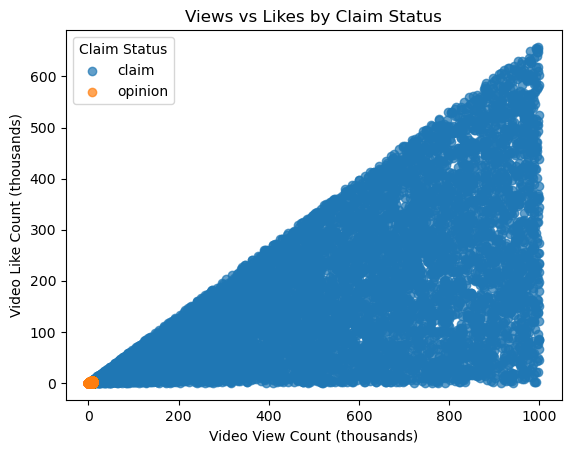

In [39]:
# Create a scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'
for status, group in data.groupby('claim_status'):
    plt.scatter(
        group['video_view_count'] / 1000,
        group['video_like_count'] / 1000,
        alpha=0.7,
        label=status
    )

plt.xlabel('Video View Count (thousands)')
plt.ylabel('Video Like Count (thousands)')
plt.title('Views vs Likes by Claim Status')
plt.legend(title='Claim Status')
plt.show()

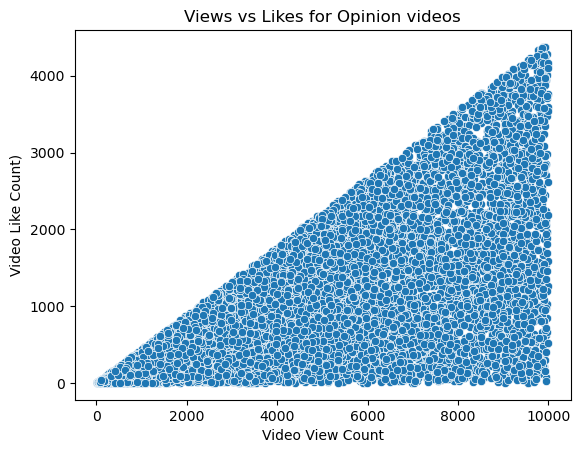

In [40]:
# Create a scatterplot of ``video_view_count` versus `video_like_count` for opinions only
opinions = data[data['claim_status'] == 'opinion']

sns.scatterplot(
    data=opinions,
    x='video_view_count',
    y='video_like_count',
  #  hue='claim_status'
)

plt.title('Views vs Likes for Opinion videos')
plt.xlabel('Video View Count')
plt.ylabel('Video Like Count)')
plt.show()


### **Create a Logistic Regression**

With the EDA complete, we will begin to explore how different variables are associated with user verification status. So far, we've seen that verified users tend to post more claims than opinions, and the opposite is true for unverified users. A logistic regression will allow us to predict user verification status based on the data points in our dataset.

In [42]:
# Remove outliers for video_like_count
def remove_outliers(df, values):
    """
    Remove outliers from a numeric column in a DataFrame using IQR method.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        column (str): Column name to check for outliers
    
    Returns:
        pd.DataFrame: DataFrame with outliers removed
    """
    if not pd.api.types.is_numeric_dtype(df[values]):
        return df
    
    iqr, median, lower_bound, upper_bound = calculate_outlier_bounds(df[values])
    
    # Keep only rows within bounds
    return df[(df[values] >= lower_bound) & (df[values] <= upper_bound)]


data_clean = remove_outliers(data, 'video_like_count')

In [43]:
#Check to ensure outliers have been removed from the data_subset
values = data['video_like_count']

iqr = values.quantile(0.75) - values.quantile(0.25)
median = values.median()

lower_bound = median - 1.5 * iqr
upper_bound = median + 1.5 * iqr

num_outliers = (
    (data_clean['video_like_count'] < lower_bound) |
    (data_clean['video_like_count'] > upper_bound)
).sum()

print(num_outliers)

0


verified_status
not verified    92.827869
verified         7.172131
Name: proportion, dtype: float64


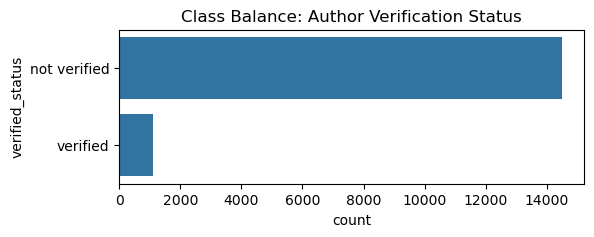

In [44]:
# Check class balance
print(data_clean['verified_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,2))
sns.countplot(y='verified_status', data=data_clean)
plt.title("Class Balance: Author Verification Status")
plt.show()

About 92.8% of the data is for data posted by unverified accounts. The data will be resampled to create class balance in the outcome variable.

In [46]:
from sklearn.utils import resample

majority = data_clean[data_clean['verified_status'] == 'not verified']
minority = data_clean[data_clean['verified_status'] == 'verified']

# Upsample the minority class
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine majority class with upsampled minority class
balanced = pd.concat([majority, minority_upsampled])

# Display new class counts
print(balanced['verified_status'].value_counts(normalize=True) * 100)

verified_status
not verified    50.0
verified        50.0
Name: proportion, dtype: float64


Next, we'll calculate the lenght of video_transcription_text so it can be used as a feature for the model.

In [48]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
balanced.insert(5, 'transcription_length', balanced['video_transcription_text'].str.len())
balanced.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,transcription_length,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,97,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,107,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,137,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,128,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,127,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0


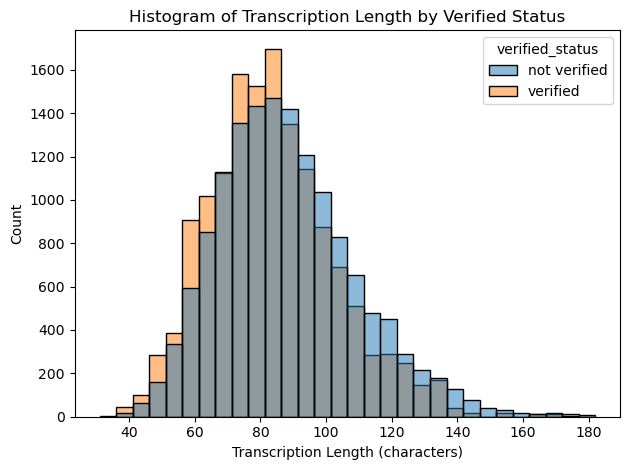

In [49]:
# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
sns.histplot(
    data=balanced,
    x='transcription_length',
    hue='verified_status',
    bins=30,
    alpha=0.5,
    multiple='layer'
)

plt.xlabel('Transcription Length (characters)')
plt.ylabel('Count')
plt.title('Histogram of Transcription Length by Verified Status')
plt.tight_layout()
plt.show()

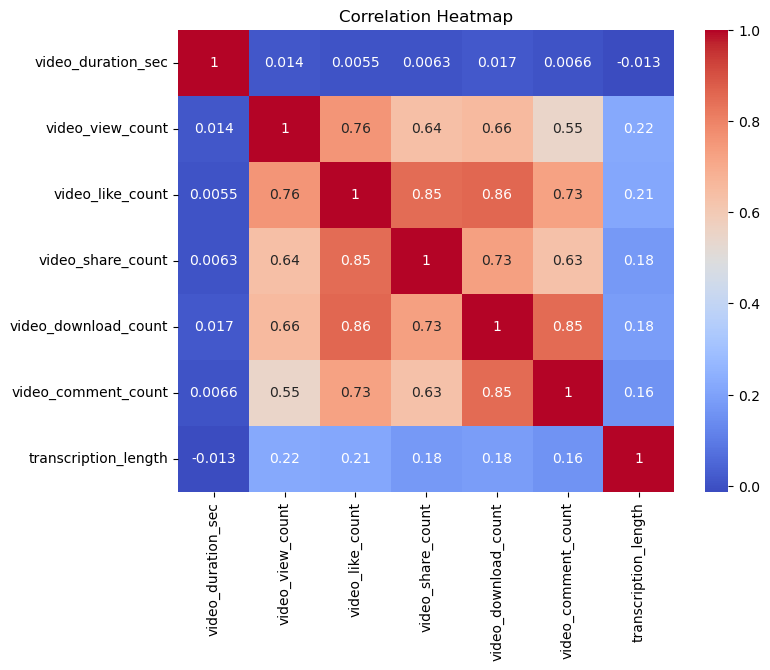

In [50]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(
    balanced[['video_duration_sec', 'claim_status', 'author_ban_status', 'video_view_count', 
                    'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count', 'transcription_length']]
    .corr(numeric_only=True), 
    annot=True, 
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

For a logistic regression model to be successful, there should not be strong multicollinearity between the features. The heatmap indicates strong correlation between video_like_count and video_share_count and video_download_count. For that reason, video_like_count will not be added as a model feature.

In [52]:
# Set variables
X = balanced[['video_duration_sec', 'claim_status', 'author_ban_status', 'video_view_count', 'video_share_count', 'video_download_count', 'video_comment_count']]
y = balanced['verified_status']

In [53]:
# Split the data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X,y, test_size=0.3, random_state=42)

Next, we'll encode the non-numerical variables.

In [55]:
X_train_lr.dtypes

video_duration_sec        int64
claim_status             object
author_ban_status        object
video_view_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
dtype: object

In [56]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_lr_to_encode = X_train_lr[['claim_status', 'author_ban_status']]
X_train_lr_encoded = encoder.fit_transform(X_train_lr_to_encode)

X_train_lr_encoded

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.]])

In [57]:
# Get feature names from encoder
encoder.get_feature_names_out()

# Add encoded features to a dataframe
X_train_lr_encoded_df = pd.DataFrame(X_train_lr_encoded, columns=encoder.get_feature_names_out())

# Drop the encoded columns from the training dataframe
X_train_lr_subset = X_train_lr.drop(columns=['claim_status', 'author_ban_status'])

# Concatenate `X_train_lr_subset` and `X_train_lr_encoded_df` to form the final dataframe for training data
X_train_lr_final = pd.concat([X_train_lr_subset.reset_index(drop=True), X_train_lr_encoded_df], axis=1)

X_train_lr_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,42,577154.0,19028.0,1874.0,379.0,0.0,0.0,1.0
1,43,2252.0,101.0,14.0,3.0,1.0,0.0,0.0
2,8,431638.0,39031.0,31.0,18.0,0.0,1.0,0.0
3,55,1199.0,26.0,4.0,0.0,1.0,0.0,0.0
4,32,5411.0,513.0,41.0,12.0,1.0,0.0,0.0


In [58]:
# Encode the training outcome variable
le = LabelEncoder()

y_train_lr_final = le.fit_transform(y_train_lr)

In [59]:
# Construct a logistic regression model and fit it to the training set
model = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_lr_final, y_train_lr_final)

Finally, we'll encode the test data and evaluate the model against that data.

In [61]:
X_test_lr_to_encode = X_test_lr[['claim_status', 'author_ban_status']]
X_test_lr_encoded = encoder.fit_transform(X_test_lr_to_encode)

# Display first few rows
X_train_lr_encoded

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 0.]])

In [62]:
# Add encoded features to a dataframe
X_test_lr_encoded_df = pd.DataFrame(X_test_lr_encoded, columns=encoder.get_feature_names_out())

# Drop the encoded columns from the test dataframe
X_test_lr.drop(columns=['claim_status', 'author_ban_status']).head()

# Concatenate `X_test_lr_subset` and `X_test_lr_encoded_df` to form the final dataframe for test data
X_test_lr_final = pd.concat([X_test_lr.drop(columns=['claim_status', 'author_ban_status']).reset_index(drop=True), X_test_lr_encoded_df], axis=1)


# Display first few rows
X_test_lr_final.head()

,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,15,655107.0,21850.0,221.0,81.0,0.0,0.0,0.0
1,18,6818.0,41.0,8.0,1.0,1.0,0.0,0.0
2,9,348.0,2.0,1.0,0.0,1.0,0.0,0.0
3,19,1478.0,95.0,2.0,1.0,1.0,0.0,0.0
4,35,4524.0,376.0,12.0,4.0,1.0,0.0,0.0


In [63]:
# Display the predictions on the encoded testing set
y_pred_lr = model.predict(X_test_lr_final)

y_pred_lr

array([0, 1, 1, ..., 1, 0, 0])

In [64]:
# Display the true labels of the testing set
y_test_lr

4682     not verified
16555    not verified
16752        verified
18103        verified
10045        verified
             ...     
12115        verified
8764     not verified
18079    not verified
4553     not verified
3610     not verified
Name: verified_status, Length: 8698, dtype: object

In [65]:
# Encode the test outcome variable
y_test_lr_final = le.fit_transform(y_test_lr)

y_test_lr_final

array([0, 0, 1, ..., 0, 0, 0])

In [66]:
# Confirm the dimensions of the training and testing sets
print(f"X_train_lr shape: {X_train_lr.shape}")
print(f"X_test_lr shape: {X_test_lr.shape}")
print(f"y_train_lr shape: {y_train_lr.shape}")
print(f"y_test_lr shape: {y_test_lr.shape}")

X_train_lr shape: (20294, 7)
X_test_lr shape: (8698, 7)
y_train_lr shape: (20294,)
y_test_lr shape: (8698,)


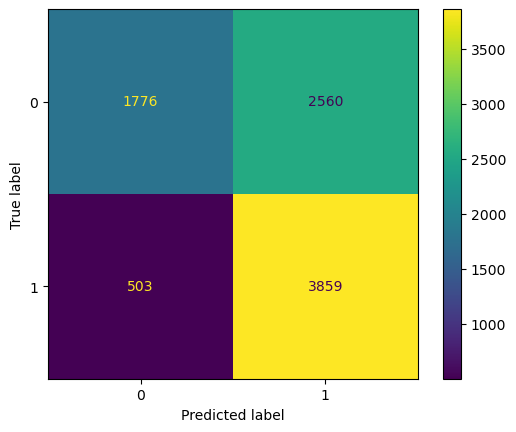

In [67]:
# Compute values for confusion matrix
cnf_matrix = confusion_matrix(y_test_lr_final, y_pred_lr, labels = model.classes_)
ConfusionMatrixDisplay(confusion_matrix = cnf_matrix,display_labels = model.classes_).plot()

In [68]:
# Create a classification report
target_labels = ["verified", "not verified"]
print(classification_report(y_test_lr_final, y_pred_lr, target_names=target_labels))

              precision    recall  f1-score   support

    verified       0.78      0.41      0.54      4336
not verified       0.60      0.88      0.72      4362

    accuracy                           0.65      8698
   macro avg       0.69      0.65      0.63      8698
weighted avg       0.69      0.65      0.63      8698



In [69]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
coefficients = model.coef_[0]
feature_names = X_train_lr_final.columns

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

coeff_df

,Feature,Coefficient
0,video_duration_sec,-8.606184e-04
1,video_view_count,-3.366322e-07
2,video_share_count,3.892333e-06
3,video_download_count,1.593002e-04
4,video_comment_count,-2.151647e-06
5,claim_status_opinion,1.777033e+00
6,author_ban_status_banned,-3.571731e-01
7,author_ban_status_under review,-2.158403e-01


In [70]:
# Create a table of results to capture model performance
log_regression_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'F1':  [f1_score(y_test_lr_final, y_pred_lr)],
    'Recall': [recall_score(y_test_lr_final, y_pred_lr)],
    'Precision': [precision_score(y_test_lr_final, y_pred_lr)],
    'Accuracy': [accuracy_score(y_test_lr_final, y_pred_lr)]
})

log_regression_results

,Model,F1,Recall,Precision,Accuracy
0,Logistic Regression,0.715889,0.884686,0.601184,0.64785


The logistic regression model correctly predicts verified users 78% of the time, and unverified (not verified) userss 60% of the time. The model's accuracy is 64.7%, and the recall score is 88.4%. Based on the feature coeffecients, video_duration_sec is the strongest predictor of verified status with a value of ~0.0086.

Next, we'll create tree models to predict whether a video represents a claim or an opinion. The data will be broken into training, test, and validation sets (60/20/20) that will be used for both a Random Forest Model and XGBoost Model. We will use cross-validation to tune the hyperparameters using the training and validation data. Once a champion model has been determined, we'll evaluate it's performance using the test data.

In [72]:
# Reset the variables from the balanced dataset for the decision tree models
X_dt_to_encode = balanced.copy()

# Drop unnecessary columns
X_dt_to_encode = X_dt_to_encode.drop(['#', 'video_id', 'video_transcription_text', 'claim_status'], axis=1)

# Identify categorical columns
data_categories_dt = ['verified_status', 'author_ban_status']

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), data_categories_dt)
    ],
    remainder='passthrough'  # keep numeric columns unchanged
)

# Fit and transform
encoded_array = preprocessor.fit_transform(X_dt_to_encode)

# Build column names
encoded_cat_cols = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(data_categories_dt)

numeric_cols = X_dt_to_encode.drop(data_categories_dt, axis=1).columns

final_columns = list(encoded_cat_cols) + list(numeric_cols)

# Convert to DataFrame
X_dt_encoded = pd.DataFrame(encoded_array, columns=final_columns, index=X_dt_to_encode.index)

X_dt = X_dt_encoded
X_dt.head()

,verified_status_verified,author_ban_status_banned,author_ban_status_under review,video_duration_sec,transcription_length,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,0.0,0.0,1.0,59.0,97.0,343296.0,19425.0,241.0,1.0,0.0
1,0.0,0.0,0.0,32.0,107.0,140877.0,77355.0,19034.0,1161.0,684.0
2,0.0,0.0,0.0,31.0,137.0,902185.0,97690.0,2858.0,833.0,329.0
4,0.0,0.0,0.0,19.0,128.0,56167.0,34987.0,4110.0,547.0,152.0
5,0.0,0.0,1.0,35.0,127.0,336647.0,175546.0,62303.0,4293.0,1857.0


In [73]:
# Encode target variable
y_dt = balanced['claim_status']

y_encoded = LabelEncoder().fit_transform(y_dt)
y_dt = y_encoded

### **Create a Random Forest Model**

In [75]:
# Split the data into training and testing sets
X_temp_dt, X_test_dt, y_temp_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.20, stratify=y, random_state=42)

In [76]:
# Split the training data into training and validation sets
X_train_dt, X_val_dt, y_train_dt, y_val_dt = train_test_split(X_temp_dt, y_temp_dt, test_size=0.25, 
                                            stratify=y_temp_dt, random_state=42)

In [77]:
# Confirm the dimensions of the training, validation and testing sets
print(f"X_temp_dt shape: {X_temp_dt.shape}")
print(f"X_test_dt shape: {X_test_dt.shape}")
print(f"y_temp_dt shape: {y_temp_dt.shape}")
print(f"y_test_dt shape: {y_test_dt.shape}")

print()

print(f"X_train_dt shape: {X_train_dt.shape}")
print(f"X_val_dt shape: {X_val_dt.shape}")
print(f"y_train_dt shape: {y_train_dt.shape}")
print(f"y_val_dt shape: {y_val_dt.shape}")

X_temp_dt shape: (23193, 10)
X_test_dt shape: (5799, 10)
y_temp_dt shape: (23193,)
y_test_dt shape: (5799,)

X_train_dt shape: (17394, 10)
X_val_dt shape: (5799, 10)
y_train_dt shape: (17394,)
y_val_dt shape: (5799,)


In [78]:
# Assign the test, validation, and training data to variables for the Random Forest Model
X_train_rf, X_val_rf, X_test_rf = X_train_dt.copy(), X_val_dt.copy(), X_test_dt.copy()
y_train_rf, y_val_rf, y_test_rf = y_train_dt.copy(), y_val_dt.copy(), y_test_dt.copy()

In [79]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [2,3,4,5, None], 
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'max_features': [2,3,4],
             'n_estimators': [75, 100, 125, 150]
             }  

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, cv=5, refit='recall', n_jobs = -1, verbose = 1)

In [80]:
%%time

### Fit the model to the data 
# rf_cv.fit(X_train_rf, y_train_rf) # comment out this line after creating pickle

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
CPU times: total: 19.9 s
Wall time: 22min 57s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, None],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [75, 100, 125, 150]},
             refit='recall', verbose=1)

In [81]:
# Examine best recall score
rf_cv.best_score_

0.9969529986953678

In [82]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 75}

In [83]:
# Access the GridSearch results and convert it to a pandas df
rf_cv_results_df = pd.DataFrame(rf_cv.cv_results_)

In [147]:
#Pickle the model. Comment out this cell after creating pickle
'''
import pickle

with open('rf_cv_model.pickle', 'wb') as to_write:
    pickle.dump(rf_cv, to_write) 
'''

In [149]:
# Open pickled model. Comment out this cell after creating pickle
'''
with open('rf_cv_model.pickle', 'rb') as to_read:
    rf_cv = pickle.load(to_read)
'''

Now we'll evaluate the results of the Random Forest Model

In [151]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred_rf = rf_cv.best_estimator_.predict(X_val_rf)

y_pred_rf

array([0, 1, 1, ..., 1, 1, 1])

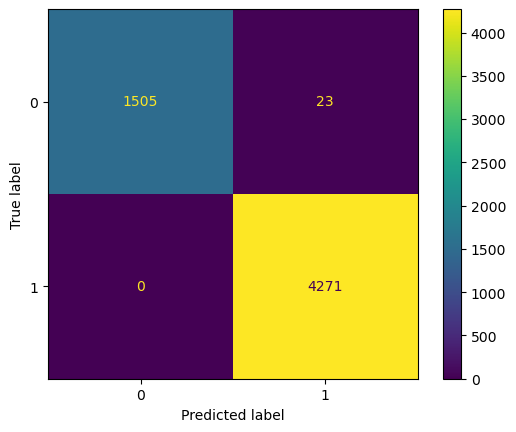

In [155]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
cm_rf = confusion_matrix(y_val_rf, y_pred_rf, labels=rf_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=rf_cv.classes_)

# Plot confusion matrix
disp_rf.plot()

In [157]:
# Create a classification report to evaluate the performance of the model
target_labels = ['opinion', 'claim']
print(classification_report(y_val_rf, y_pred_rf, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       1.00      0.98      0.99      1528
       claim       0.99      1.00      1.00      4271

    accuracy                           1.00      5799
   macro avg       1.00      0.99      0.99      5799
weighted avg       1.00      1.00      1.00      5799



In [159]:
# Create a table of results to capture model performance
rf_cv_results = pd.DataFrame({
    'Model': ['Random Forest'],
    'F1':  [f1_score(y_val_rf, y_pred_rf)],
    'Recall': [recall_score(y_val_rf, y_pred_rf)],
    'Precision': [precision_score(y_val_rf, y_pred_rf)],
    'Accuracy': [accuracy_score(y_val_rf, y_pred_rf)]
})

rf_cv_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.997315,1.0,0.994644,0.996034


The model predicted 99.6% of the data points correctly. It correctly predicted all true positives, and only predicted 23 false positives.

### **Create an XGBoost Model**

In [162]:
# Assign the test, validation, and training data to variables for the XGBoost Model
X_train_xgb, X_val_xgb, X_test_xgb = X_train_dt.copy(), X_val_dt.copy(), X_test_dt.copy()
y_train_xgb, y_val_xgb, y_test_xgb = y_train_dt.copy(), y_val_dt.copy(), y_test_dt.copy()

In [164]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42) 

# Create a dictionary of hyperparameters to tune
cv_params_xgb = {'max_depth': [4,5,10], 
             'min_child_weight': [3,5],
             'learning_rate': [0.2, 0.3],
             'n_estimators': [5, 10, 20],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
             } 

# Define a list of scoring metrics to capture
scoring_xgb = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params_xgb, scoring=scoring_xgb, cv=5, refit='recall')

In [170]:
%%time

# Fit the model to the data
# xgb_cv.fit(X_train_xgb, y_train_xgb) # comment out this line after creating pickle

CPU times: total: 56.5 s
Wall time: 17 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.2, 0.3],
                         'max_depth': [4, 5, 10], 'min_child_weight': [3, 5],
                         'n_estimators': [5, 10, 20], 'subsample': [0.7]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [172]:
# Examine best recall score
xgb_cv.best_score_

1.0

In [174]:
# Examine best parameters
xgb_cv.best_params_

{'colsample_bytree': 0.7,
 'learning_rate': 0.2,
 'max_depth': 4,
 'min_child_weight': 3,
 'n_estimators': 5,
 'subsample': 0.7}

In [176]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###
xgb_cv_results_df = pd.DataFrame(xgb_cv.cv_results_)
xgb_cv_results_df.columns

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_cv_results_df['mean_test_precision'][xgb_cv.best_index_]

0.9935637850155139

In [178]:
#Pickle the model. Comment out this cell after creating pickle
'''
import pickle

with open('xgb_cv_model.pickle', 'wb') as to_write:
    pickle.dump(xgb_cv, to_write) 
'''

In [180]:
# Open pickled model. Comment out this cell after creating pickle
'''
with open('xgb_cv_model.pickle', 'rb') as to_read:
    xgb_cv = pickle.load(to_read)
'''

In [182]:
# Use the best estimator to predict on the validation data
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val_xgb)

y_pred_xgb

array([0, 1, 1, ..., 1, 1, 1])

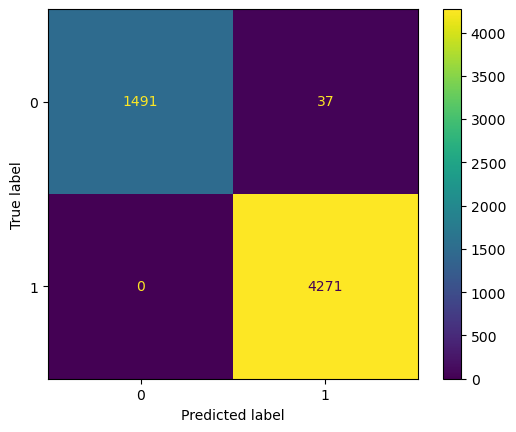

In [186]:
# Compute values for confusion matrix
cm_xgb = confusion_matrix(y_val_xgb, y_pred_xgb, labels=xgb_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                              display_labels=xgb_cv.classes_)

# Plot confusion matrix
disp_xgb.plot()

In [188]:
# Create a classification report
print(classification_report(y_val_xgb, y_pred_xgb, target_names=target_labels))

              precision    recall  f1-score   support

     opinion       1.00      0.98      0.99      1528
       claim       0.99      1.00      1.00      4271

    accuracy                           0.99      5799
   macro avg       1.00      0.99      0.99      5799
weighted avg       0.99      0.99      0.99      5799



In [207]:
# Create a table of results to capture model performance
xgb_cv_results = pd.DataFrame({
    'Model': ['XGBoost'],
    'F1':  [f1_score(y_val_xgb, y_pred_xgb)],
    'Recall': [recall_score(y_val_xgb, y_pred_xgb)],
    'Precision': [precision_score(y_val_xgb, y_pred_xgb)],
    'Accuracy': [accuracy_score(y_val_xgb, y_pred_xgb)]
})

xgb_cv_results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost,0.995687,1.0,0.991411,0.99362


The XGBoost Model performed similiar to the Random Forest Model. It predicted 99.4% of the data points correctly. It correctly predicted all true positives, and only predicted 37 false positives.

**Use the Champion Model to preodict on test data**

In [209]:
champ_cv_results = pd.concat([rf_cv_results, xgb_cv_results], ignore_index=True)

champ_cv_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.997315,1.0,0.994644,0.996034
1,XGBoost,0.995687,1.0,0.991411,0.993620


While the results of both models are similar, the Random Forest Model performed slightly better than the XGBoost Model.

In [201]:
y_pred_champ = rf_cv.best_estimator_.predict(X_test_rf)

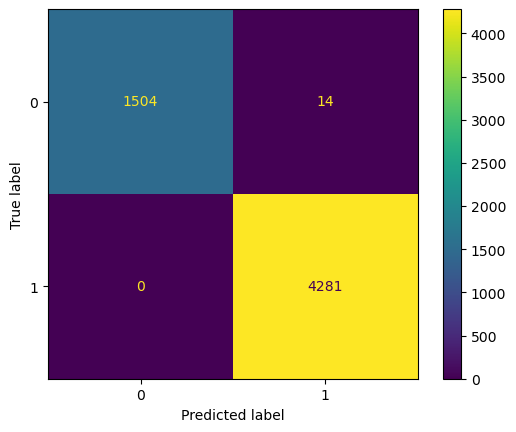

In [203]:
# Compute values for confusion matrix
cm_champ = confusion_matrix(y_test_rf, y_pred_champ, labels=rf_cv.classes_)

# Create display of confusion matrix using ConfusionMatrixDisplay()
disp_champ = ConfusionMatrixDisplay(confusion_matrix=cm_champ,
                              display_labels=rf_cv.classes_)

# Plot confusion matrix
disp_champ.plot()

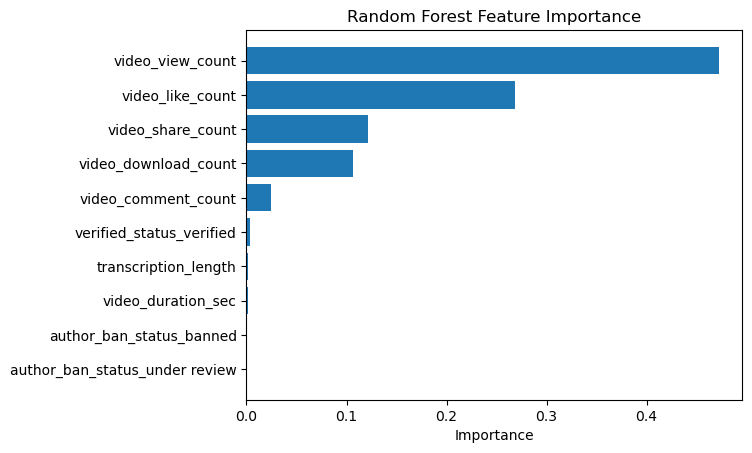

In [211]:
# Evaluate the feature importances of champion model
importances = rf_cv.best_estimator_.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

The most important features were video_view_count and video_like_count. This is an expected result as we expect a correlation between video engagement and claim status.

The model has high scores on all metrics - precision, recall, accuracy, and F1. Given that it successfully predicts whether a video represents a claim or an opinion based on user engagement, I would recommend TikTok use this model to classify videos on its platform.